# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Stin D.`  
**SFU ID:** `301556417`  
**Date:** `June 1st`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

Fix pandas reading NA as NaN with this stack code: https://stackoverflow.com/questions/41417214/prevent-pandas-from-reading-na-as-nan

In [2]:
# Fix NA being read as NaN
na_values = ["", 
             "#N/A", 
             "#N/A N/A", 
             "#NA", 
             "-1.#IND", 
             "-1.#QNAN", 
             "-NaN", 
             "-nan", 
             "1.#IND", 
             "1.#QNAN", 
             "<NA>", 
             "N/A",
             "NULL", 
             "NaN", 
             "n/a", 
             "nan", 
             "null"]

df_ab = pd.read_csv('phigma_ab_study.csv', na_values=na_values, keep_default_na=False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [3]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [4]:
# Missing values
df_ab.isnull().sum()


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

The team randomly assigned free-tier users to one of two conditions during a 14-day observation window: access to a new AI design assistant (treatment) or no AI access (control). 

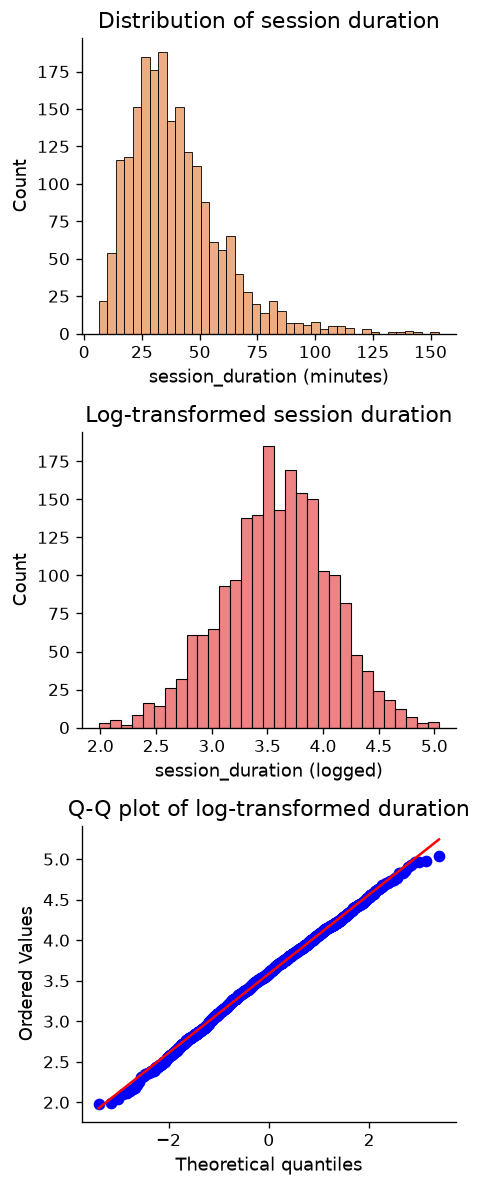

Raw distribution skewness: 1.3768
Log-transformed distribution skewness: -0.1629


In [5]:
#BEGIN
#Load target outcome variable
outcome = df_ab["avg_whiteboard_session_duration_min"]

#// 1. Normality & Transformation Visualizations
#Initialize three-panel visual layout
fig, axes = plt.subplots(3, 1, figsize=(4, 10))

#Draw histogram of raw outcome distribution
sns.histplot(outcome,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of session duration")
axes[0].set_xlabel("session_duration (minutes)")

#Transform outcome variable using natural logarithm
outcome_logged = np.log1p(df_ab["avg_whiteboard_session_duration_min"])

#Draw histogram of log-transformed outcome distribution
sns.histplot(outcome_logged,
             color="#e85a5a",
             ax=axes[1])
axes[1].set_title("Log-transformed session duration")
axes[1].set_xlabel("session_duration (logged)")

#Draw Q-Q plot comparing log-transformed distribution to a normal distribution
import scipy.stats as stats
stats.probplot(outcome_logged, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of log-transformed duration")

#Render visualizations
sns.despine()
plt.tight_layout()
plt.show()

#// 2. Statistical Diagnostics
#Compute and output skewness for both raw and log-transformed distributions
# If closer to 0 then indicates a symmetrical (normal) distribution
# higher numbers = data that is skewed
print(f"Raw distribution skewness: {outcome.skew():.4f}")
print(f"Log-transformed distribution skewness: {outcome_logged.skew():.4f}")

#END

**✏️ Your interpretation (A1.1):**

The log outcome is more normally distributed than the raw data. 

When we printed the skewness for both the raw and logged data we got these two numbers: 

> Raw distribution skewness: 1.3768

> Log-transformed distribution skewness: -0.1629

Anything greater than 1 indicates a strong positive skewness while the log-transformed distrubution is between -0.5 and 0.5 which indicates symmetrical data.

When we look at the histogram graphs, the raw data has a long right tail. After logging, the tail gets pulled inwards and the data becomes centred. 

The Q-Q plot helps us support this conclusion because it plots the logged-outcome distributions against the "normal" expected version of it. Because the line is straight and diagonal, it means it behaves just like the theoritical normal distrubution would.

**I will use the logged outcome data in my model** because it means the outliers or errors of the original data are distrubuted normally and not in a way that accidentally skews it to the right. This will ensure we analyze typical user behaviour instead of the odd one out.

#### A1.2 — Examine the confounders

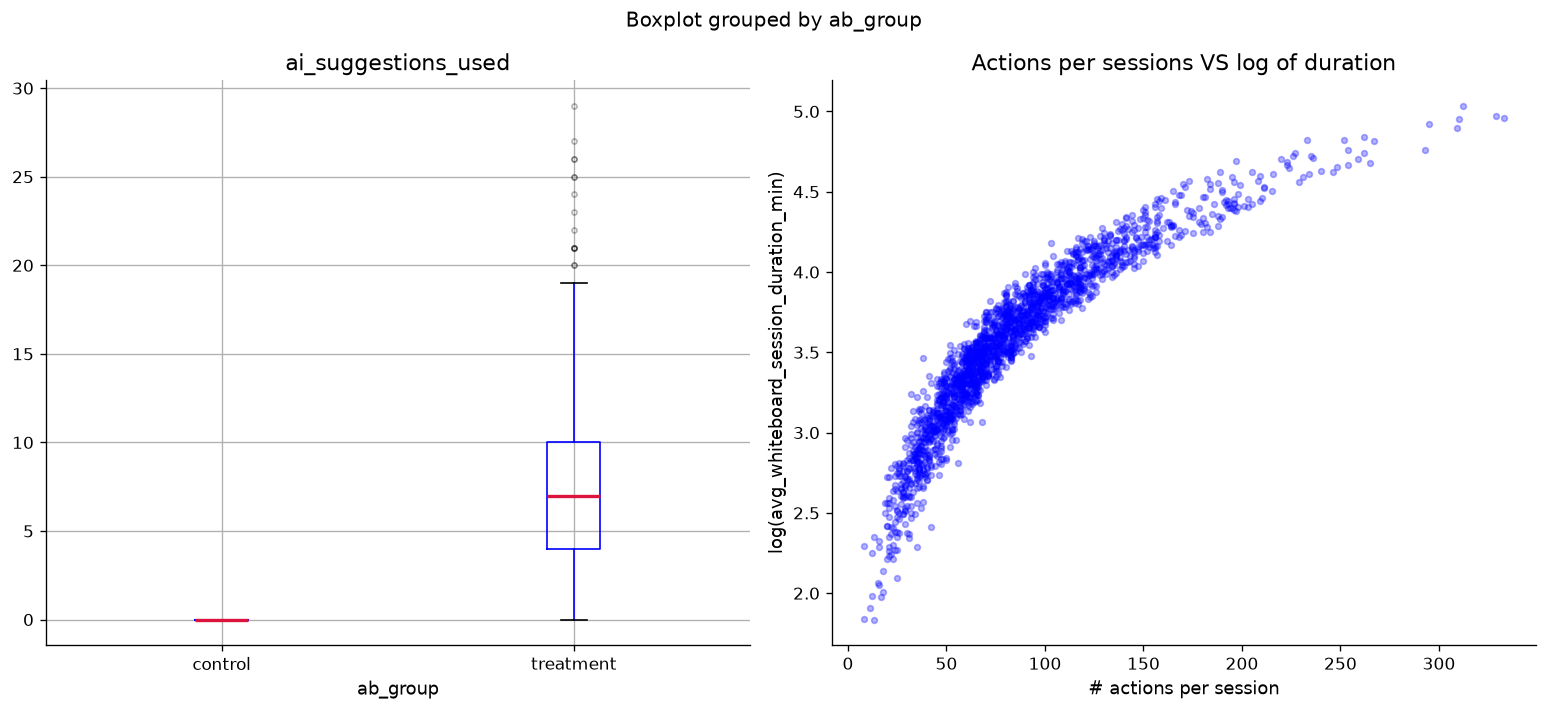

Pearson-r (whiteboard_actions_per_session vs log_duration): 0.9136

Descriptive stats for ai_suggestions_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [6]:
#BEGIN

#// 1. Visual Exploratory Data Analysis
#Initialize side-by-side visualization layouts
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

#Draw boxplot comparison of AI suggestion usage across experimental groups
df_ab.boxplot(column='ai_suggestions_used', by='ab_group', ax=axes[0],
              boxprops=dict(color='blue'), medianprops=dict(color='crimson', lw=2),
              whiskerprops=dict(color='blue'), capprops=dict(color='black'),
              flierprops=dict(marker='o', color='red', alpha=0.3, markersize=3)
              )

#Draw scatter plot comparing whiteboard activity density against session durations
log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])
axes[1].scatter(df_ab['whiteboard_actions_per_session'], log_dur, color='blue',
                alpha=0.3, s=12)
axes[1].set_title('Actions per sessions VS log of duration')
axes[1].set_xlabel('# actions per session')
axes[1].set_ylabel('log(avg_whiteboard_session_duration_min)')

#Optimize layout and display visualizations
plt.tight_layout()
plt.show()

#// 2. Statistical Analysis
#Calculate and print the correlation between whiteboard activity and session duration
corr_actions = df_ab['whiteboard_actions_per_session'].corr(log_dur)
print(f"Pearson-r (whiteboard_actions_per_session vs log_duration): {corr_actions:.4f}")
#Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
print("\nDescriptive stats for ai_suggestions_used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))

#END

**✏️ Your interpretation (A1.2):**

The control group used 0 ai suggestions while the treatment group used them an average of 7 times. This means the control group was successful in that they had no ai assistant access.

The correlation 0.9136 suggests that the number of actions per session dynamically increases with duration. Theres a very strong correlation between those two. So they're measuring the same thing which is user engagement.

We **can't use either of them in our model** because these variables/outcomes are calculated **after** the study treatment is done and **not before**. 

The ai auggestions and the whiteboard actions happened during the 2 week study and are directly influenced by access to the tool. it might measure a non-ai experienced user against an an non-experienced user and conclude they must have the same skill level to begin with. It makes the predication of whether having AI increases engagement be based on false contextual data.


#### A1.3 — Predictor distributions and relationships with outcome

*** account_age_days ***
*** prior_whiteboard_sessions ***
*** num_collaborators ***


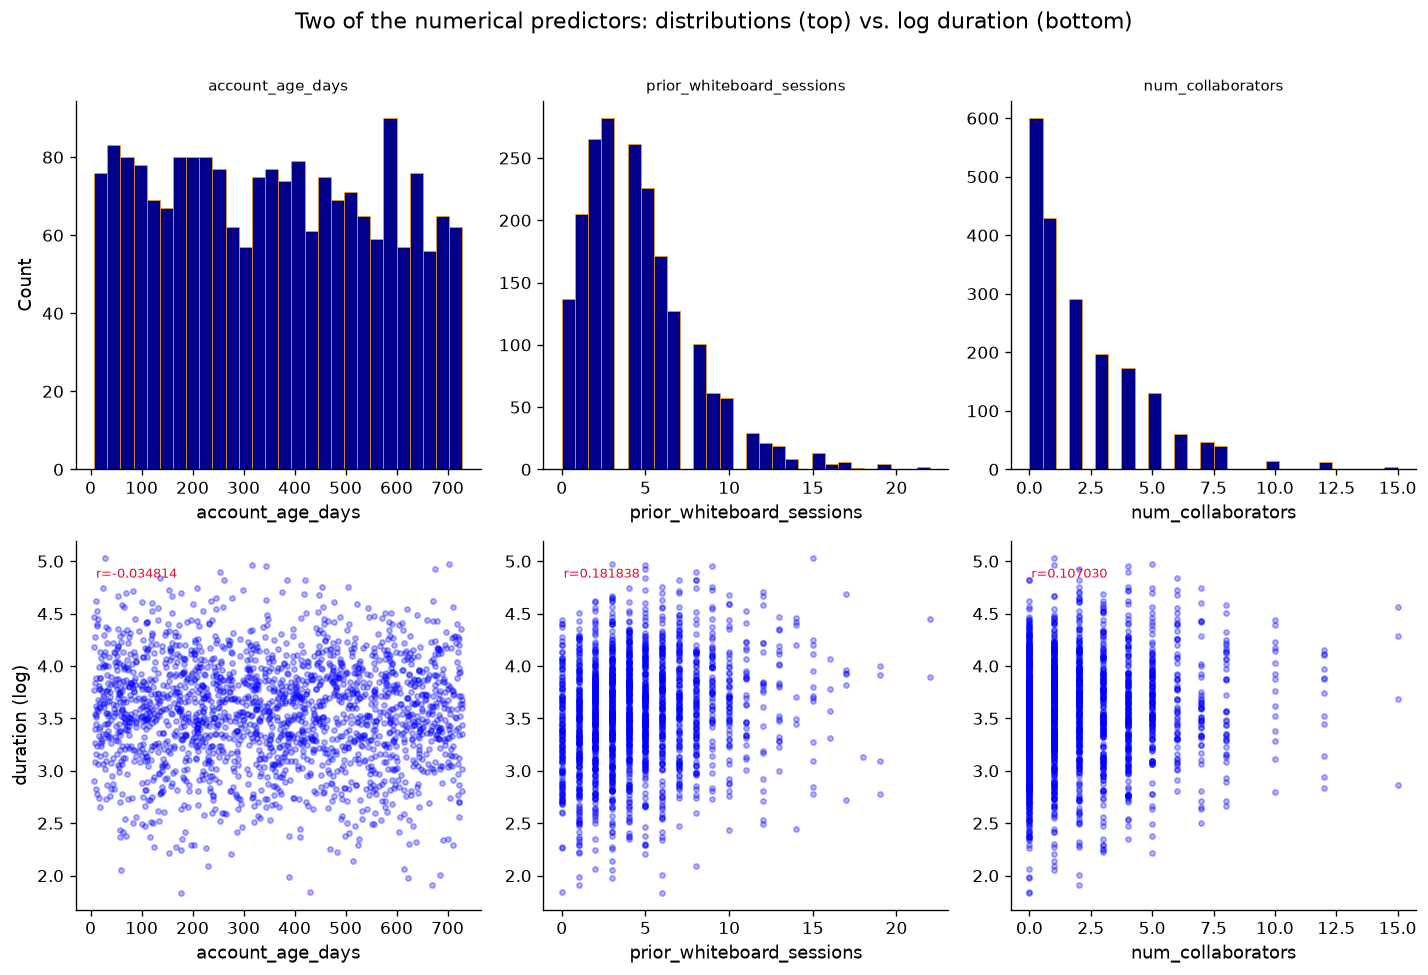

In [9]:
#BEGIN
    #Define list of numerical predictor variables
num_predictors = [
    'account_age_days',
    'prior_whiteboard_sessions',
    'num_collaborators'
]
n = len(num_predictors)

#Compute log-transformed outcome variable
#log_dur

#Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle('Two of the numerical predictors: distributions (top) vs. log duration (bottom)',
            fontsize=13, y=1.01)

#FOR each predictor variable:
for j, col in enumerate(num_predictors):
    print("***", col, "***")
     #   // Top row: Univariate Analysis
     #   Draw histogram to show distribution of the predictor
    axes[0,j].hist(df_ab[col], bins=28, color='darkblue', edgecolor='orange', lw=0.4)
    axes[0,j].set_title(col, fontsize=9)
    axes[0,j].set_xlabel(col)
    axes[0,j].set_ylabel('Count' if j == 0 else '')
        
     #   // Bottom row: Bivariate Analysis
     #   Draw scatter plot comparing predictor against log-transformed outcome 
    axes[1,j].scatter(df_ab[col], log_dur, color='blue', alpha=0.3, s=10)
    axes[1,j].set_xlabel(col)
    axes[1,j].set_ylabel('duration (log)' if j == 0 else '')
     #   Calculate correlation coefficient between predictor and log-transformed outcome
    r = df_ab[col].corr(log_dur)
     #   Annotate plot with correlation coefficient
    axes[1,j].annotate(f'r={r:2f}',xy=(0.05,0.9),
                       xycoords='axes fraction', fontsize=8, color='crimson')
    #END FOR

#Add global title and render layout
plt.tight_layout()
plt.show()

#END

*** ab_group unique levels: <StringArray>
['control', 'treatment']
Length: 2, dtype: str ***

*** device_type unique levels: <StringArray>
['tablet', 'desktop', 'mobile']
Length: 3, dtype: str ***

*** plan_region unique levels: <StringArray>
['EU', 'APAC', 'NA', 'LATAM']
Length: 4, dtype: str ***



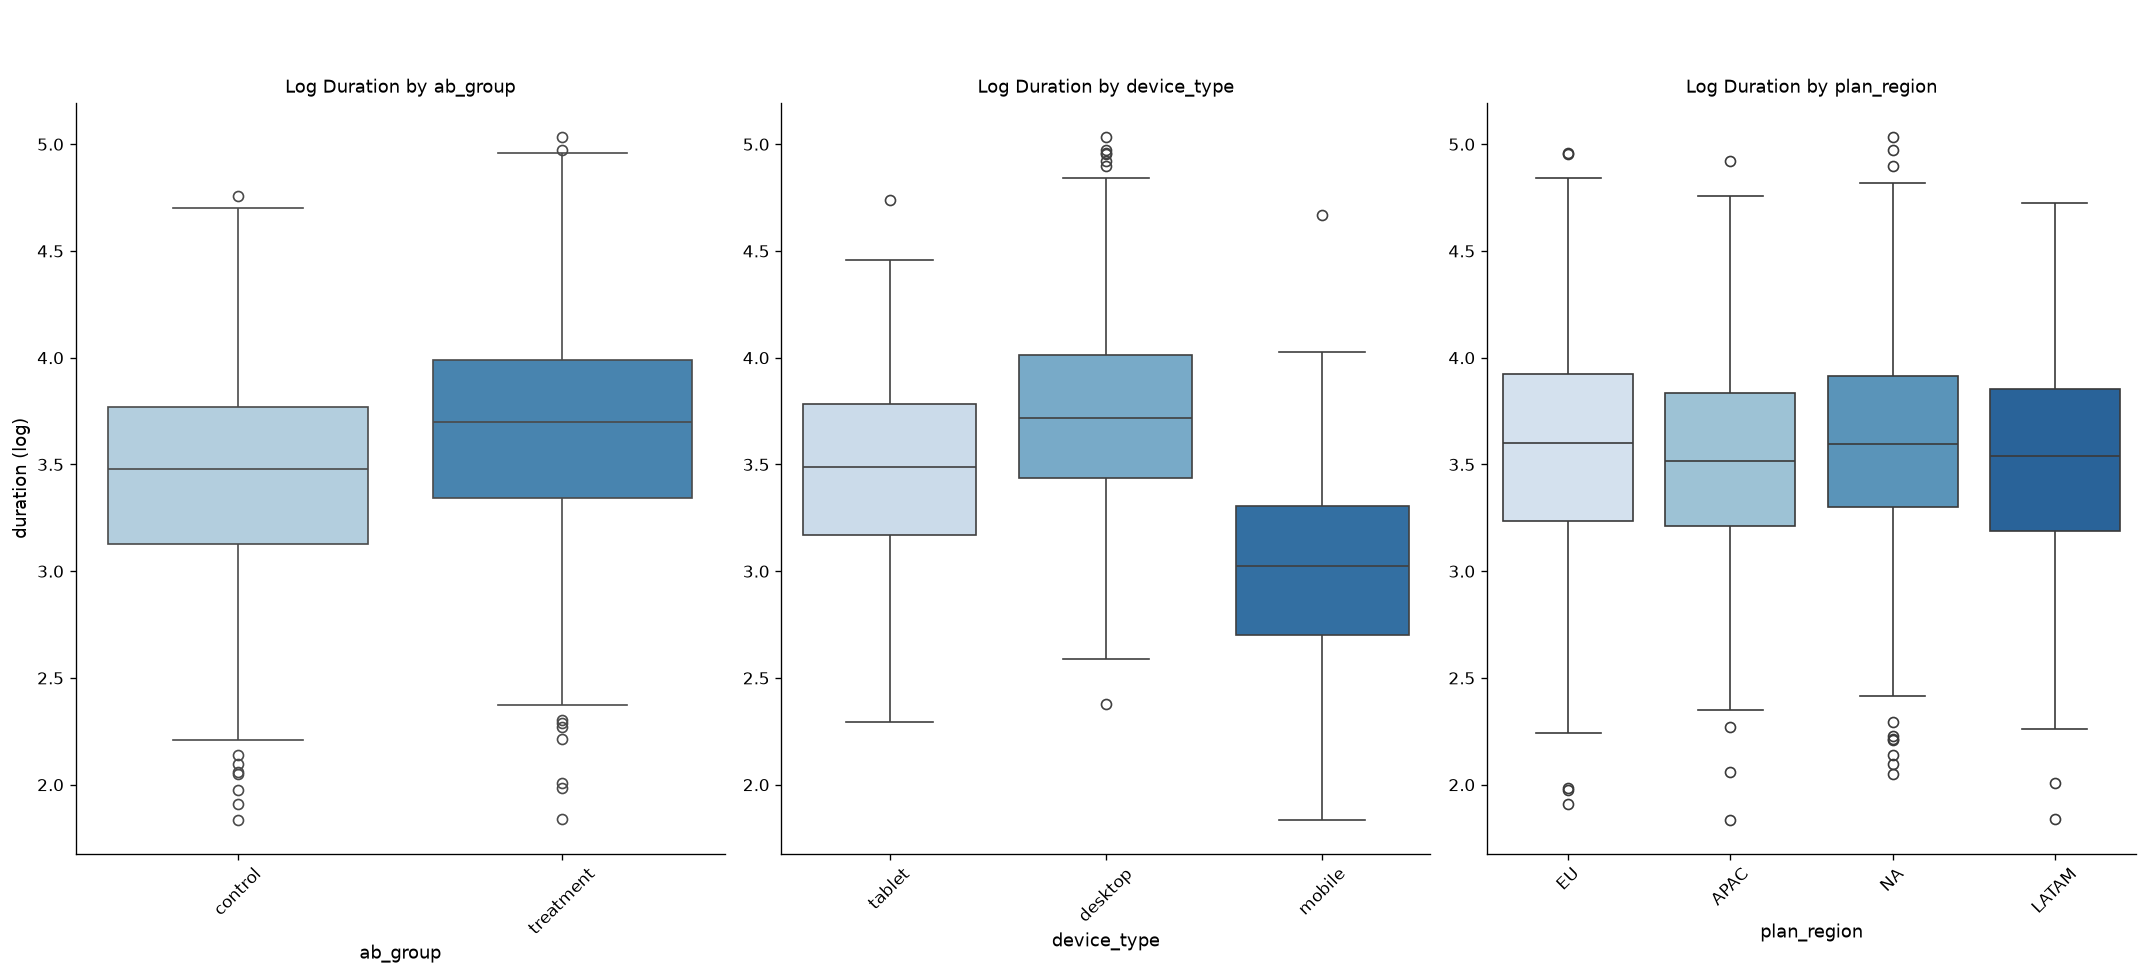

In [10]:
#BEGIN
    #Define list of categorical predictor variables
#device_type, plan_regionm, log_dur
cat_predictors = ["ab_group", "device_type", "plan_region"]
n = len(cat_predictors)

    #Initialize visual grid layout (1 row by N columns, where N is the number of categories)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 8))
fig.suptitle(' ',
            fontsize=13, y=1.01)

    #FOR each categorical variable:
for j, col in enumerate(cat_predictors):
    #Retrieve unique category levels
    unique_levels = df_ab[col].unique()
    print(f"*** {col} unique levels: {unique_levels} ***\n")
    #Group log-transformed outcome values by category levels
    #Draw boxplots of log-transformed outcome grouped by category level
    sns.boxplot(x=df_ab[col], y=log_dur, ax=axes[j], palette='Blues')
    #Rotate category axis labels for readability
    axes[j].tick_params(axis="x", rotation=45)

    #Label axis and set titles
    axes[j].set_title(f"Log Duration by {col}", fontsize=11)
    axes[j].set_xlabel(col)
    axes[j].set_ylabel("duration (log)" if j == 0 else "")
#END FOR

#Render layout
sns.despine()
plt.tight_layout()
plt.show()
#END

**✏️ Your interpretation (A1.3):**

**Numerical Predictors:**

'prior_whiteboard_sessions' & 'num_collaborators' show a weak positive correlation to the duration, meanwhile 'account_age_days' correlation is almost 0 meaning it almost doesn't affect duration at all. The small correlation values tells us these are pre-treatment variables and are safe to include without heavily skewing the outcome.

**Categorical Predictors**

The median line for 'plan_region' are pretty much all aligned even with outliers, meaning the difference in region doesn't affect session length much. Meanwhile the median line for 'device_type' and specifically 'desktop' looks very promising as the median line is above the other two device types. The model will adjust for the fact that having a computer means staying longer on the whiteboard.

**Log-skewing & Exclusions**

I will log skew `num_collaborators` as a vast majority have 1-2 teammates with a few jumping to 10-15. The right tail on `prior_whiteboard_sessions` need logging as well.

**Excluded:** `whiteboard_actions_per_session` & `ai_suggestions_used` which are post-treatment varaibles and will break the model. `account_age_days` has almost 0 correlation so it will also be dropped.

One-hot-encoding for `plan_region` & `device_type`

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [17]:
#BEGIN
    #Load baseline dataset
    #// 1. Encode Categorical Variables
    #Convert experimental group ('ab_group') into a binary integer indicator
df_ab["is_treatment"] = (df_ab["ab_group"] == "treatment").astype(int)

    #Generate dummy indicators (one-hot encoding) for device types, omitting the first category
device_dummy = pd.get_dummies(
    df_ab["device_type"], prefix="device", drop_first=True, dtype=int
)
    #Generate dummy indicators (one-hot encoding) for regions, omitting the first category
region_dummy = pd.get_dummies(
    df_ab["plan_region"], prefix="region", drop_first=True, dtype=int
)
    #// 2. Perform Optional Transformations
    #Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values
df_ab["log_prior_sessions"] = np.log1p(df_ab["prior_whiteboard_sessions"])
df_ab["log_num_collaborators"] = np.log1p(df_ab["num_collaborators"])

    #// 3. Assemble Modeling Dataset
    #Merge numerical characteristics, binary groups, and dummy indicators into matrix X
# select logged columns
num_features = df_ab[["log_prior_sessions", "log_num_collaborators"]]
# axis=1 to merge columns instead of rows
X = pd.concat(
    [num_features, df_ab["is_treatment"], device_dummy, region_dummy],
    axis=1,
)
    #Set target vector y as the log-transformed outcome variable
y = log_dur

    #// 4. Quality Control
    #Verify that there are no missing (null) values in feature matrix X
has_missing = X.isna().any().any()
print(has_missing)

assert X.isnull().sum().sum() == 0
print(f"Missing X values: {X.isnull().sum().sum()}")

    #Inspect matrix dimensions and print a preview of the processed data
print(f"\nFeature Matrix X Dimensions: {X.shape}")
print(f"Target Vector y Dimensions: {y.shape}")
print("\n--- Preview of Processed Feature Matrix X ---")
print(X.head())
#END

False
Missing X values: 0

Feature Matrix X Dimensions: (2000, 8)
Target Vector y Dimensions: (2000,)

--- Preview of Processed Feature Matrix X ---
   log_prior_sessions  log_num_collaborators  is_treatment  device_mobile  \
0            1.609438               1.386294             0              0   
1            2.302585               0.693147             0              0   
2            2.397895               1.791759             0              0   
3            1.791759               0.693147             0              0   
4            1.386294               0.000000             0              1   

   device_tablet  region_EU  region_LATAM  region_NA  
0              1          1             0          0  
1              0          0             0          0  
2              0          0             0          1  
3              0          0             0          1  
4              0          0             0          1  


**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*

`log_prior_sessions` Numerical: Logged due to strong positive right-skew. Included as base user experience.

`log_num_collaborators` Numerical: Logged because of jump in team mate numbers (right skew). Included as baseline team scale.

`is_treatment` Binary: Whether the user had access to AI or not
- (0=control, 1=treatment)

`device_mobile` Dummy: Whether the device was mobile (lower baseline)

`device_tablet` Dummy: Whether the device was tablet (specific baseline)

`region_EU` Dummy: European users

`region_LATAM` Dummy: Latin American users

`region_NA` Dummy: North American users

3 regions were included to not muddy statistics with only one region's stats.



### A3 — OLS Regression


In [18]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.357
Model:                                             OLS   Adj. R-squared:                  0.354
Method:                                  Least Squares   F-statistic:                     138.0
Date:                                 Wed, 01 Jul 2026   Prob (F-statistic):          1.43e-184
Time:                                         17:03:05   Log-Likelihood:                -1030.3
No. Observations:                                 2000   AIC:                             2079.
Df Residuals:                                     1991   BIC:                             2129.
Df Model:                                            8                                         
Covariance Type:                             nonrobust                                         
                            coef    std 

#### A3.1 — Interpret the model

In [25]:
#     Input trained OLS regression model
#     Input experimental dataframe

#     // 1. Evaluate Model Fit
#     Display model's R-squared value to assess variance explained
print(f"R^2         = {model_ols.rsquared:.4f}")
print(f"Adj. R^2    = {model_ols.rsquared_adj:.4f}\n")

#     // 2. Analyze Treatment Effect
#     Extract coefficient and significance (p-value) for the A/B testing variable
ab_coef = model_ols.params['is_treatment']
ab_pval = model_ols.pvalues['is_treatment']
ab_percent_change = (np.exp(ab_coef) - 1) * 100

#     Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
control_mean = df_ab.loc[df_ab['ab_group'] == 'control', 'avg_whiteboard_session_duration_min'].mean()
ab_mins_effect = control_mean * (ab_percent_change / 100)

#     Display treatment effect size and statistical significance
print(f"ab_group coefficient:   {ab_coef:.4f}")
print(f"pvalue              :   {ab_pval:.4f}")
# turn coef into percentage
print(f"back-transformed    :   {ab_percent_change:.1f}% relative to control mean")
print(f"absolute impact     :   {ab_mins_effect:.1f} min above control baseline ({control_mean:.1f} min)")

#     // 3. Extract Significant Predictors
#     Filter all model coefficients where p-value < 0.05
sig_pvalues = model_ols.pvalues[model_ols.pvalues < 0.05].sort_values()
print('\nsignificant predictors are:')

#     FOR each significant variable:
#         Display variable name, its directional coefficient, and its p-value
for var, pv in sig_pvalues.items():
    coef = model_ols.params[var]
    print(f"  {var:<25s} . coef = {coef: .4f} . p = {pv:.4f}")

R^2         = 0.3567
Adj. R^2    = 0.3541

ab_group coefficient:   0.2171
pvalue              :   0.0000
back-transformed    :   24.3% relative to control mean
absolute impact     :   8.5 min above control baseline (35.2 min)

significant predictors are:
  const                     . coef =  3.2758 . p = 0.0000
  device_mobile             . coef = -0.7263 . p = 0.0000
  is_treatment              . coef =  0.2171 . p = 0.0000
  device_tablet             . coef = -0.2581 . p = 0.0000
  log_prior_sessions        . coef =  0.1410 . p = 0.0000
  log_num_collaborators     . coef =  0.0869 . p = 0.0000
  region_NA                 . coef =  0.0824 . p = 0.0006
  region_EU                 . coef =  0.0759 . p = 0.0020


**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*

`is_treatment` indicates whether the group had access to the ai suggestions. The OLS model showed us that it has both a significant p-value (less than 0.05) and a coefficent of 0.2 indicating a small positive overrall effect. When we transformed the logged session duration back to a percentage, we got a 24.3% increase in average whiteboard session time. The null hypothesis is rejected by the p-value findings proving this is not just by random sample chance but an actual result of the treatment.

The model's R² and adjusted R² are both around 0.35. That means roughly 35% of the total variance in our whiteboard session durations can be explained by our chosen variables like the choice of hardware device and account history statistics.

Two notable predictors are `device_mobile` which has a coefficient of around -0.7 indicating a strong negative effect (time goes down if the user is on mobile), and `log_prior_sessions` with a coefficient of 0.1 which indicates a positive effect (depending on the users amount of prior sessions, the duration goes up). Both these predictors have a p value of 0 which shows statistical significance. 

The stats and the model tell us the AI assistant's effect is real and substantial. The practical significance can be visualized if we imagine incorporating this 24.3% increase of session time back into the average session of 35.2 mins. It gives us an extra 8.5 extra minutes of session time. It is a pretty substantial boost to the average time when added up for every user.

#### A3.2 — Regression diagnostics

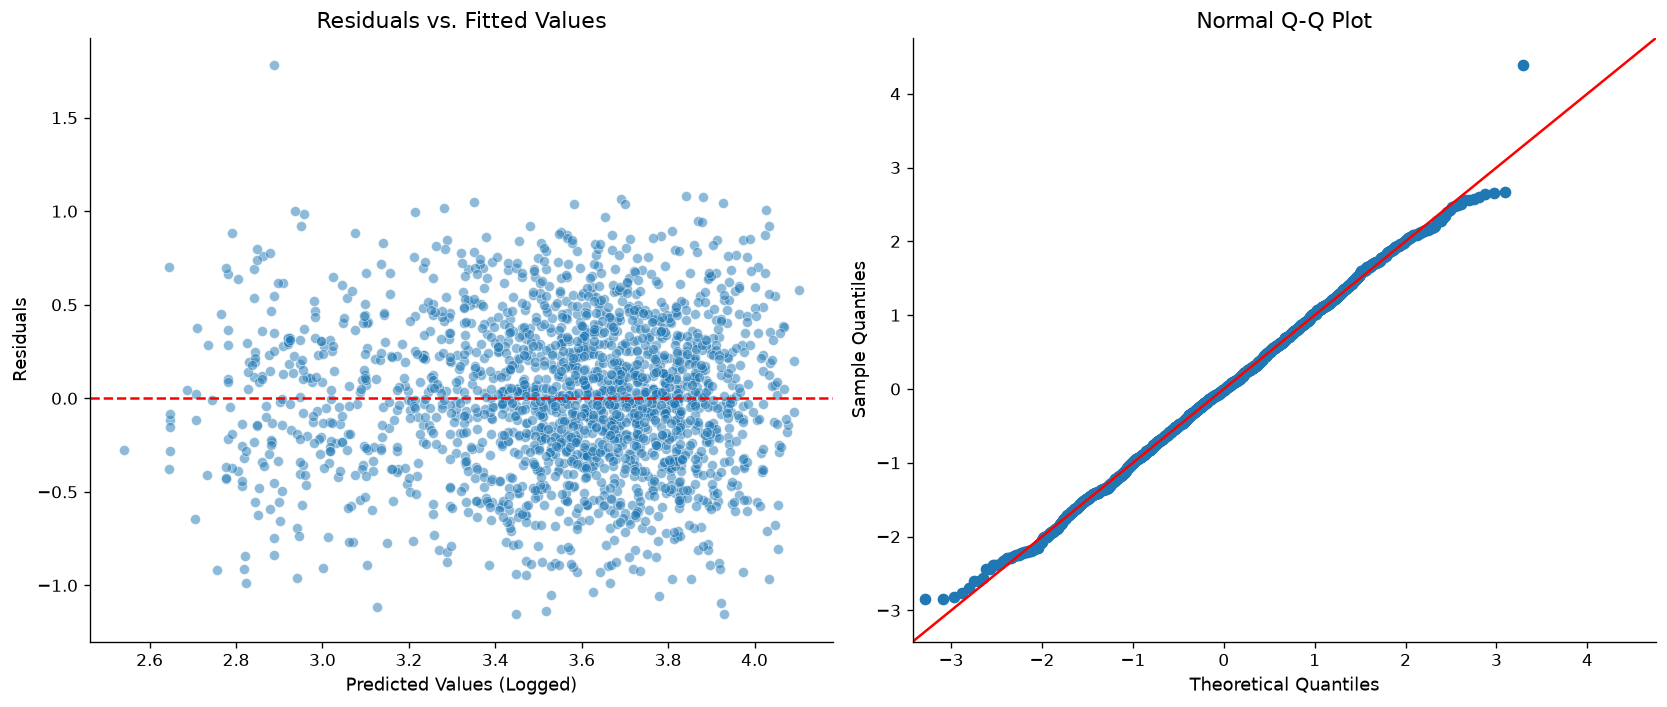

In [28]:
# BEGIN
# Extract predictions and error terms (residuals) from regression model
fitted_values = model_ols.fittedvalues
residuals = model_ols.resid

# Initialize a side-by-side diagnostic visualization layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# // Check for uniform variance (homoscedasticity)
# Draw scatter plot of prediction values vs residuals
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.5, ax=axes[0])
# Overlay a horizontal zero-error baseline reference line
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Residuals vs. Fitted Values")
axes[0].set_xlabel("Predicted Values (Logged)")
axes[0].set_ylabel("Residuals")

# // Check for normality of errors
# Draw a Q-Q plot of residuals against a normal theoretical distribution
sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")

# Render diagnostic plots
plt.tight_layout()
plt.show()
# END

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*

The residuals are indeed randomly scattered around zero. This means the extra noise of our data is consistent (unbiased + homoscedasticity is met), the outliers do not skew the data extremely one way or another, and the relationship is reasonably linear.

The majority of dots on the Q-Q plot follow the fitted line meaning the skews we had in our data before got neutralized. 

The only one concern is that stray dot that jumps way above the fitted line. This indicates that specific user's whiteboard session was significantly longer than what the model predicted. It is a outlier. 

Even though both ends of the q-q plot's tail start peeling away from the line, a majority of the sample size is fitted well confirming our model's reliability.


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*

I will test the interaction between `is_treatment` (access to ai assistant) and `log_prior_sessions` (user's prior experience with the whiteboard).

A brand new user will have less prior experience (lower `log_prior_sessions`) and therefore have a harder time using the whiteboard than someone whose used to the Phigma UI. If we give these new users an AI assistant, will it actually help them use & learn the whiteboard effectively or just overwhelm them?

Prediction: Experienced users will benefit from the AI assistant more than new users because they already understand how to use the whiteboard. The AI assistant will just enhance their actions and knowledge, whereas the AI will add to the discomfort of new users trying to learn the UI.


In [29]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']
X_interact = X_const.copy()
X_interact["treatment_x_prior_sessions"] = (
    X_interact["is_treatment"] * X_interact["log_prior_sessions"]
)

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())

model_interact = sm.OLS(y, X_interact).fit()
print(model_interact.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.358
Model:                                             OLS   Adj. R-squared:                  0.355
Method:                                  Least Squares   F-statistic:                     123.1
Date:                                 Thu, 02 Jul 2026   Prob (F-statistic):          3.92e-184
Time:                                         00:41:13   Log-Likelihood:                -1028.8
No. Observations:                                 2000   AIC:                             2078.
Df Residuals:                                     1990   BIC:                             2134.
Df Model:                                            9                                         
Covariance Type:                             nonrobust                                         
                                 coef   

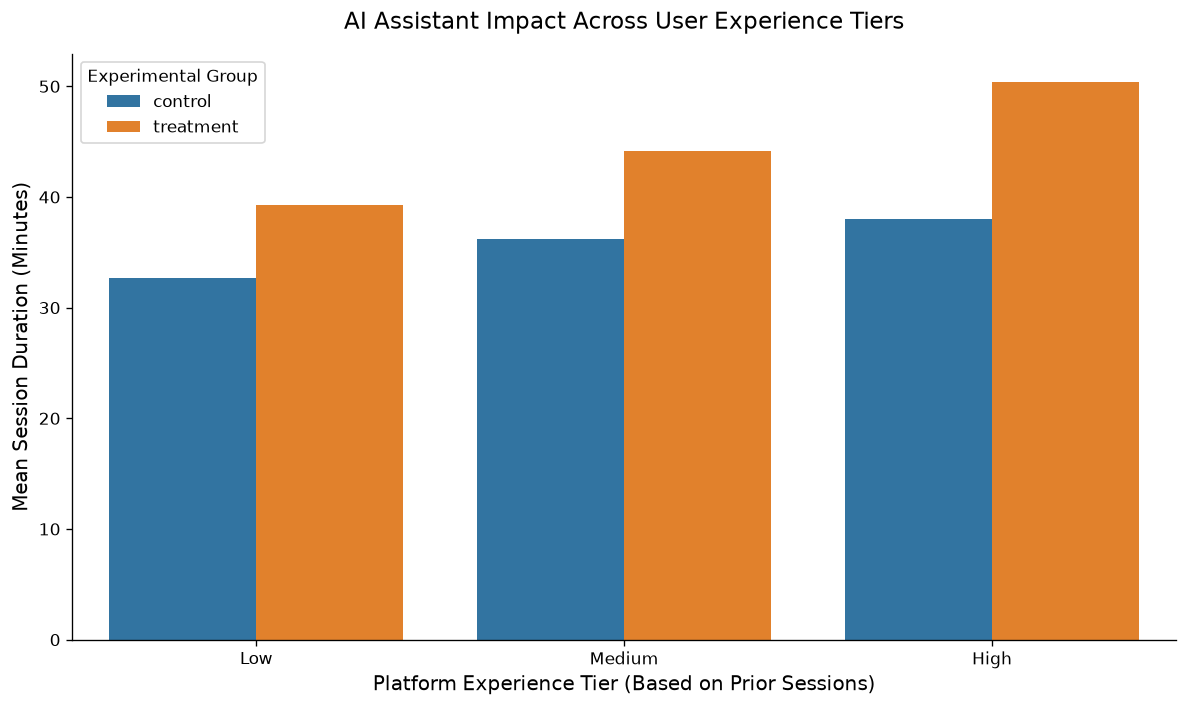

In [ ]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines

# qcut into 3 equal buckets - 33% of users who fall into these categories
df_ab["experience_tier"] = pd.qcut(
    df_ab["log_prior_sessions"], q=3, labels=["Low", "Medium", "High"]
)

# group experience with AB groups and the average whiteboard session
grouped_data = (df_ab.groupby(["experience_tier", "ab_group"])["avg_whiteboard_session_duration_min"].mean().reset_index())

# grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped_data,
    x="experience_tier",
    y="avg_whiteboard_session_duration_min",
    hue="ab_group",
)

plt.title(
    "AI Assistant Impact Across User Experience Tiers", fontsize=14, pad=15
)
plt.xlabel("Platform Experience Tier (Based on Prior Sessions)", fontsize=12)
plt.ylabel("Mean Session Duration (Minutes)", fontsize=12)
plt.legend(title="Experimental Group")
sns.despine()

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*

The regression table for `treatment_x_prior_sessions` gives us it's coefficient of 0.0478 and its p-value of 0.084. Because the p-value is greater than our threshold of 0.05 and we can't reject the null hypothesis. This boost to experienced users might just be due to random sample variation. Meanwhile, the positive coefficient does point to a slightly stronger effect for more experienced users. The plain coefficient for `is_treatment` is much more promising at 0.1448 which means the AI helps everyone regardless of experience.

The graph meanwhile does visually support our hypothesis but this boost seems to apply to everyone in the treatment group anyways regardless of the user's prior experience. 

For Phigma, this implies they should launch this feature for all users as session durations increase across the board but the AI should be intuitive enough that it doesn't overwhelm new users while experienced users can still take advantage of its full capabilities. 

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [34]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                           str
signup_date                       str
first_session_date                str
device_type                       str
country_tier                      str
referral_source                   str
num_sessions_30d                int64
total_time_min_30d              int64
projects_created_30d            int64
exports_30d                     int64
collaborators_invited_30d       int64
support_tickets_30d             int64
used_premium_feature_preview    int64
ai_assistant_sessions_30d       int64
subscribed                      int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [35]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [36]:
# YOUR CODE HERE

# 1. Parse dates
# df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
# df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
# df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
# df_sub['avg_session_duration_min'] = ...

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
# df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
# device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
# referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)
# y_sub = df_sub['subscribed']

# Confirm
# print(f"Any inf: {np.isinf(X_sub.values).any()}")
# print(f"Any NaN: {X_sub.isnull().any().any()}")
# print(f"Feature matrix shape: {X_sub.shape}")
# X_sub.head(3)


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*


### B2 — EDA for Subscription


In [ ]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
# axes[0]: ...

# Plot 2 — YOUR CODE
# axes[1]: ...

# Plot 3 — YOUR CODE
# axes[2]: ...

plt.tight_layout()
plt.show()


In [ ]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
# X_const_sub = sm.add_constant(X_sub)
# model_logit = sm.Logit(y_sub, X_const_sub).fit()
# print(model_logit.summary())


In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# odds_ratios = np.exp(model_logit.params)
# conf_int    = np.exp(model_logit.conf_int())
# Combine into a readable table and display
# Filter to significant only: p < 0.05


In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*


### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
# fig, ax = plt.subplots(figsize=(5, 4))
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.title('Logistic Regression — Confusion Matrix')
# plt.show()


In [ ]:
# YOUR CODE HERE
# Classification report
# print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8)
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve — Logistic Regression')
# ax.legend()
# plt.show()


**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


In [ ]:
# YOUR CODE HERE
# Confusion matrix


In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)


### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)


In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
